# Step 03 — Preprocessing: ERA5 + Labels → Model-Ready Arrays
**Project:** ENSO-BSISO Self-Supervised Learning  
**Author:** Jiayi (jh9141@nyu.edu)

This notebook aligns ERA5 atmospheric fields with the BSISO/ENSO labels and builds
the final input arrays for model training.

**Inputs (from Google Drive `data/raw/`):**
- `u850_v850_July_YYYY_YYYY.nc` × 5 chunks — ERA5 wind at 850 hPa
- `OLR_July_1979_2023.nc` — ERA5 top net thermal radiation
- `labels.csv` — BSISO phase + ENSO category (from notebook 02)

**Outputs (saved to `data/processed/`):**
- `X_July.npy` — shape `(N, 3, 31, 51)`, float32, z-score normalized
- `labels_aligned.csv` — labels for the N aligned days
- `norm_stats.json` — per-channel mean and std used for normalization

**Grid:** 31 lat × 51 lon (0–60°N, 60–160°E, 2° resolution)  
**Channels:** 0=u850, 1=v850, 2=OLR  
**Expected N:** ~1,333 July days (1981–2023)

---

## Cell 1 — Mount Google Drive + Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import pandas as pd
import xarray as xr

PROJECT_DIR  = '/content/drive/MyDrive/BSISO_SSL_Project'
RAW_DIR      = f'{PROJECT_DIR}/data/raw'
PROCESSED_DIR = f'{PROJECT_DIR}/data/processed'

os.makedirs(PROCESSED_DIR, exist_ok=True)

print('Google Drive mounted.')
print('Files in raw/:')
for f in sorted(os.listdir(RAW_DIR)):
    mb = os.path.getsize(f'{RAW_DIR}/{f}') / 1e6
    print(f'  {f}  ({mb:.1f} MB)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Files in raw/:
  BSISO.INDEX.NORM.LY.data  (1.1 MB)
  OLR_July_1979_2023.nc  (4.8 MB)
  labels.csv  (0.1 MB)
  nino34_monthly.txt  (0.1 MB)
  u850_v850_July_1979_1989.nc  (2.9 MB)
  u850_v850_July_1990_1999.nc  (2.7 MB)
  u850_v850_July_2000_2009.nc  (2.7 MB)
  u850_v850_July_2010_2019.nc  (2.7 MB)
  u850_v850_July_2020_2023.nc  (1.1 MB)


## Cell 2 — Load and Concatenate ERA5 Wind Files

Wind data was downloaded in 5 year-chunks. We merge them into one array.  
Variable names: `u`, `v`  
Time dimension: `valid_time` (contains 12:00 UTC timestamps)  
Extra dimension: `pressure_level` (always 850 hPa — will be squeezed out)

In [ ]:
wind_files = sorted([
    f'{RAW_DIR}/{f}' for f in os.listdir(RAW_DIR)
    if f.startswith('u850_v850_July') and f.endswith('.nc')
])

print(f'Found {len(wind_files)} wind files:')
for f in wind_files:
    print(f'  {os.path.basename(f)}')

# Open each file and squeeze out the pressure_level dimension
datasets = []
for f in wind_files:
    ds = xr.open_dataset(f).squeeze('pressure_level', drop=True)
    datasets.append(ds)

# Concatenate along valid_time
ds_wind = xr.concat(datasets, dim='valid_time').sortby('valid_time')

print(f'\nMerged wind dataset:')
print(ds_wind)
print(f'\nDate range: {str(ds_wind.valid_time.values[0])[:10]} '
      f'to {str(ds_wind.valid_time.values[-1])[:10]}')
print(f'Total time steps: {len(ds_wind.valid_time)}')
print(f'Grid: {len(ds_wind.latitude)} lat × {len(ds_wind.longitude)} lon')
print(f'u range: [{float(ds_wind["u"].min()):.2f}, {float(ds_wind["u"].max()):.2f}] m/s')

Found 5 wind files:
  u850_v850_July_1979_1989.nc
  u850_v850_July_1990_1999.nc
  u850_v850_July_2000_2009.nc
  u850_v850_July_2010_2019.nc
  u850_v850_July_2020_2023.nc

Merged wind dataset:
<xarray.Dataset> Size: 18MB
Dimensions:     (valid_time: 1395, latitude: 31, longitude: 51)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 11kB 1979-07-01T12:00:00 ... 2023...
  * latitude    (latitude) float64 248B 60.0 58.0 56.0 54.0 ... 6.0 4.0 2.0 0.0
  * longitude   (longitude) float64 408B 60.0 62.0 64.0 ... 156.0 158.0 160.0
    number      int64 8B 0
    expver      (valid_time) <U4 22kB '0001' '0001' '0001' ... '0001' '0001'
Data variables:
    u           (valid_time, latitude, longitude) float32 9MB 2.813 ... 7.991
    v           (valid_time, latitude, longitude) float32 9MB 0.3009 ... 5.644
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             C

## Cell 3 — Load ERA5 OLR

Variable: `ttr` (top net thermal radiation, J/m²)  
ERA5 convention: negative = radiation going out (upward). We negate to get positive OLR-like values.  
Exact unit conversion does not matter for model training (data will be z-score normalized).

In [ ]:
olr_path = f'{RAW_DIR}/OLR_July_1979_2023.nc'
ds_olr = xr.open_dataset(olr_path)

print('OLR dataset:')
print(ds_olr)
print(f'\nDate range: {str(ds_olr.valid_time.values[0])[:10]} '
      f'to {str(ds_olr.valid_time.values[-1])[:10]}')
print(f'Total time steps: {len(ds_olr.valid_time)}')
print(f'Raw ttr range:    [{float(ds_olr["ttr"].min()):.0f}, {float(ds_olr["ttr"].max()):.0f}] J/m²')
print(f'After negation:   [{float(-ds_olr["ttr"].max()):.0f}, {float(-ds_olr["ttr"].min()):.0f}] J/m²')

OLR dataset:
<xarray.Dataset> Size: 9MB
Dimensions:     (valid_time: 1395, latitude: 31, longitude: 51)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 11kB 1979-07-01T12:00:00 ... 2023...
  * latitude    (latitude) float64 248B 60.0 58.0 56.0 54.0 ... 6.0 4.0 2.0 0.0
  * longitude   (longitude) float64 408B 60.0 62.0 64.0 ... 156.0 158.0 160.0
    number      int64 8B ...
    expver      (valid_time) <U4 22kB ...
Data variables:
    ttr         (valid_time, latitude, longitude) float32 9MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-03T03:33 GRIB to CDM+CF via cfgrib-0.9.1...

Date range: 1979-07-01 to 2023-07-31
Total time steps: 1395
Raw ttr range:    [-1480402, -271940] J/m²
After negation:   [271940, 148040

## Cell 4 — Load Labels

In [ ]:
labels_path = f'{RAW_DIR}/labels.csv'
df_labels = pd.read_csv(labels_path, parse_dates=['date'])

# Normalize to date-only (midnight) for matching
df_labels['date'] = df_labels['date'].dt.normalize()

print(f'Labels loaded: {len(df_labels)} rows')
print(f'Date range: {df_labels["date"].min().date()} to {df_labels["date"].max().date()}')
print(f'\nPhase distribution:')
print(df_labels['bsiso_phase'].value_counts().sort_index())
print(f'\nENSO distribution:')
print(df_labels['enso_category'].value_counts())
print()
print(df_labels.head())

Labels loaded: 1333 rows
Date range: 1981-07-01 to 2023-07-31

Phase distribution:
bsiso_phase
1    192
2    184
3    195
4    125
5    135
6    169
7    134
8    199
Name: count, dtype: int64

ENSO distribution:
enso_category
Neutral    775
La Nina    341
El Nino    217
Name: count, dtype: int64

        date  bsiso_phase  bsiso_amplitude  nino34_jja enso_category
0 1981-07-01            3            0.845   -0.543333       La Nina
1 1981-07-02            3            1.181   -0.543333       La Nina
2 1981-07-03            3            1.140   -0.543333       La Nina
3 1981-07-04            3            1.292   -0.543333       La Nina
4 1981-07-05            3            1.359   -0.543333       La Nina


## Cell 5 — Align Dates (ERA5 ∩ Labels)

ERA5 `valid_time` contains 12:00 UTC timestamps. Labels contain date-only.  
We normalize both to midnight and take the intersection.

In [ ]:
# Normalize ERA5 timestamps to date-only
wind_dates = pd.DatetimeIndex(ds_wind.valid_time.values).normalize()
olr_dates  = pd.DatetimeIndex(ds_olr.valid_time.values).normalize()
label_dates = pd.DatetimeIndex(df_labels['date'])

# Find intersection of all three
common_dates = wind_dates.intersection(olr_dates).intersection(label_dates).sort_values()

print(f'ERA5 wind dates:  {len(wind_dates):4d} days  '
      f'({wind_dates[0].date()} to {wind_dates[-1].date()})')
print(f'ERA5 OLR dates:   {len(olr_dates):4d} days  '
      f'({olr_dates[0].date()} to {olr_dates[-1].date()})')
print(f'Label dates:      {len(label_dates):4d} days  '
      f'({label_dates[0].date()} to {label_dates[-1].date()})')
print(f'\nCommon dates:     {len(common_dates):4d} days  '
      f'({common_dates[0].date()} to {common_dates[-1].date()})')
print(f'Expected:         ~1333 July days (1981-2023)')

# Build date → index maps for fast lookup
wind_date_to_idx  = {pd.Timestamp(t).normalize(): i
                     for i, t in enumerate(ds_wind.valid_time.values)}
olr_date_to_idx   = {pd.Timestamp(t).normalize(): i
                     for i, t in enumerate(ds_olr.valid_time.values)}
label_date_to_idx = {t: i for i, t in enumerate(label_dates)}

ERA5 wind dates:  1395 days  (1979-07-01 to 2023-07-31)
ERA5 OLR dates:   1395 days  (1979-07-01 to 2023-07-31)
Label dates:      1333 days  (1981-07-01 to 2023-07-31)

Common dates:     1333 days  (1981-07-01 to 2023-07-31)
Expected:         ~1333 July days (1981-2023)


## Cell 6 — Build (N, 3, H, W) Array

Channels:  
- 0: u850 (zonal wind)  
- 1: v850 (meridional wind)  
- 2: OLR = -ttr (negated top net thermal radiation)

In [ ]:
N     = len(common_dates)
n_lat = len(ds_wind.latitude)
n_lon = len(ds_wind.longitude)

print(f'Building array: ({N}, 3, {n_lat}, {n_lon}) ...')
print(f'Estimated memory: {N * 3 * n_lat * n_lon * 4 / 1e6:.1f} MB')

# Load all ERA5 data into numpy first (faster than repeated xarray selects)
u_all   = ds_wind['u'].values.astype(np.float32)    # (T_wind, lat, lon)
v_all   = ds_wind['v'].values.astype(np.float32)    # (T_wind, lat, lon)
olr_all = (-ds_olr['ttr'].values).astype(np.float32) # (T_olr, lat, lon), negated

# Build array
X = np.zeros((N, 3, n_lat, n_lon), dtype=np.float32)

for i, date in enumerate(common_dates):
    wi = wind_date_to_idx[date]
    oi = olr_date_to_idx[date]
    X[i, 0] = u_all[wi]
    X[i, 1] = v_all[wi]
    X[i, 2] = olr_all[oi]
    if i % 200 == 0:
        print(f'  {i+1}/{N}  ({date.date()})')

print(f'\nDone!  X shape: {X.shape},  dtype: {X.dtype}')
print(f'Memory: {X.nbytes / 1e6:.1f} MB')
print(f'\nPer-channel ranges (before normalization):')
for ch, name in enumerate(['u850', 'v850', 'OLR']):
    print(f'  {name}: [{X[:, ch].min():.2f}, {X[:, ch].max():.2f}]')

Building array: (1333, 3, 31, 51) ...
Estimated memory: 25.3 MB
  1/1333  (1981-07-01)
  201/1333  (1987-07-15)
  401/1333  (1993-07-29)
  601/1333  (2000-07-12)
  801/1333  (2006-07-26)
  1001/1333  (2013-07-09)
  1201/1333  (2019-07-23)

Done!  X shape: (1333, 3, 31, 51),  dtype: float32
Memory: 25.3 MB

Per-channel ranges (before normalization):
  u850: [-53.89, 47.44]
  v850: [-42.39, 55.75]
  OLR: [271940.00, 1480402.00]


## Cell 7 — Z-Score Normalize Per Channel

Each channel is normalized to zero mean and unit variance across all (N × H × W) values.  

⚠️ **Note:** This uses statistics from the full dataset (all years). Once the train/val split
is finalized, recompute `mean` and `std` using **training data only** and re-normalize.
The `norm_stats.json` file records the values used here.

In [ ]:
norm_stats = {}
X_norm = X.copy()

for ch, name in enumerate(['u850', 'v850', 'OLR']):
    mu    = float(X[:, ch].mean())
    sigma = float(X[:, ch].std())
    X_norm[:, ch] = (X[:, ch] - mu) / sigma
    norm_stats[name] = {'mean': mu, 'std': sigma}
    print(f'{name}:  mean = {mu:+.4f},  std = {sigma:.4f}')

print(f'\nAfter normalization — per-channel check (should be ~0 mean, ~1 std):')
for ch, name in enumerate(['u850', 'v850', 'OLR']):
    print(f'  {name}: mean = {X_norm[:, ch].mean():.6f},  std = {X_norm[:, ch].std():.6f}')

u850:  mean = +1.9931,  std = 6.3460
v850:  mean = +0.6897,  std = 4.4754
OLR:  mean = +846781.5000,  std = 181322.4375

After normalization — per-channel check (should be ~0 mean, ~1 std):
  u850: mean = 0.000000,  std = 1.000000
  v850: mean = 0.000000,  std = 1.000000
  OLR: mean = -0.000000,  std = 1.000000


## Cell 8 — Save Outputs to Google Drive

In [ ]:
# Align labels to common_dates (same order as X_norm)
df_aligned = df_labels[df_labels['date'].isin(common_dates)].copy()
df_aligned = df_aligned.sort_values('date').reset_index(drop=True)

# Verify row order matches X_norm
assert list(df_aligned['date']) == list(common_dates), \
    'Date order mismatch between X_norm and labels — check alignment!'

# Save
X_path     = f'{PROCESSED_DIR}/X_July.npy'
y_path     = f'{PROCESSED_DIR}/labels_aligned.csv'
stats_path = f'{PROCESSED_DIR}/norm_stats.json'

np.save(X_path, X_norm)
df_aligned.to_csv(y_path, index=False)
with open(stats_path, 'w') as f:
    json.dump(norm_stats, f, indent=2)

print('Saved to Google Drive:')
for path in [X_path, y_path, stats_path]:
    mb = os.path.getsize(path) / 1e6
    print(f'  ✓ {os.path.basename(path)}  ({mb:.2f} MB)')

Saved to Google Drive:
  ✓ X_July.npy  (25.29 MB)
  ✓ labels_aligned.csv  (0.06 MB)
  ✓ norm_stats.json  (0.00 MB)


## Cell 9 — Verification Report + Plot

PREPROCESSING VERIFICATION REPORT
X_July.npy shape:      (1333, 3, 31, 51)  (N, channels, lat, lon)
Total samples (N):     1333
Date range:            1981-07-01 to 2023-07-31
Channels:              [0] u850  [1] v850  [2] OLR
Grid:                  31 lat (0–60°N)  ×  51 lon (60–160°E)

Normalization stats (Approach A — full-dataset z-score):
  u850: mean = +1.9931,  std = 6.3460
  v850: mean = +0.6897,  std = 4.4754
  OLR: mean = +846781.5000,  std = 181322.4375

BSISO phase distribution:
bsiso_phase
1    192
2    184
3    195
4    125
5    135
6    169
7    134
8    199

ENSO category distribution:
enso_category
Neutral    775
La Nina    341
El Nino    217

Bin counts (BSISO phase × ENSO):
enso_category  El Nino  La Nina  Neutral
bsiso_phase                             
1                   31       39      122
2                   31       35      118
3                   36       41      118
4                   20       27       78
5                   32       25       78
6          

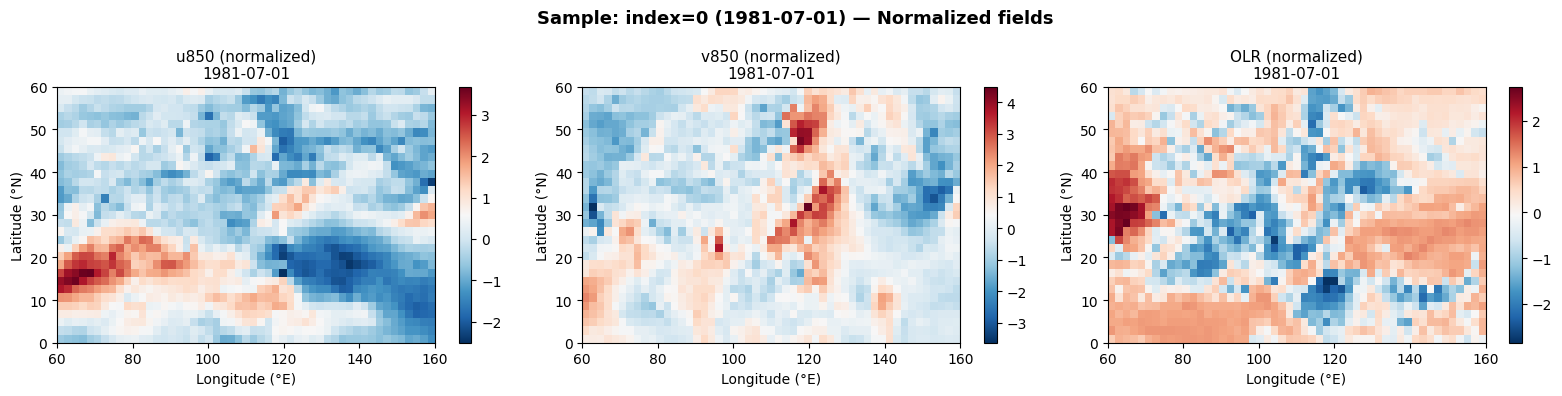

Plot saved: /content/drive/MyDrive/BSISO_SSL_Project/results/preprocessing_sample.png


In [ ]:
import matplotlib.pyplot as plt

print('=' * 60)
print('PREPROCESSING VERIFICATION REPORT')
print('=' * 60)
print(f'X_July.npy shape:      {X_norm.shape}  (N, channels, lat, lon)')
print(f'Total samples (N):     {N}')
print(f'Date range:            {common_dates[0].date()} to {common_dates[-1].date()}')
print(f'Channels:              [0] u850  [1] v850  [2] OLR')
print(f'Grid:                  {n_lat} lat (0–60°N)  ×  {n_lon} lon (60–160°E)')
print()
print('Normalization stats (Approach A — full-dataset z-score):')
for name, s in norm_stats.items():
    print(f'  {name}: mean = {s["mean"]:+.4f},  std = {s["std"]:.4f}')
print()
print('BSISO phase distribution:')
print(df_aligned['bsiso_phase'].value_counts().sort_index().to_string())
print()
print('ENSO category distribution:')
print(df_aligned['enso_category'].value_counts().to_string())
print()
print('Bin counts (BSISO phase × ENSO):')
ct = pd.crosstab(df_aligned['bsiso_phase'], df_aligned['enso_category'])
print(ct)
print()
print('(Check: no bin should be 0 — every phase/ENSO combo needs training samples)')
print('=' * 60)

# Plot: sample day (index 0)
channel_names = ['u850 (normalized)', 'v850 (normalized)', 'OLR (normalized)']
cmaps = ['RdBu_r', 'RdBu_r', 'RdBu_r']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ch, (ax, name, cmap) in enumerate(zip(axes, channel_names, cmaps)):
    im = ax.imshow(X_norm[0, ch], cmap=cmap, origin='upper',
                   extent=[60, 160, 0, 60], aspect='auto')
    ax.set_title(f'{name}\n{common_dates[0].date()}', fontsize=11)
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude (°N)')
    plt.colorbar(im, ax=ax)

plt.suptitle(f'Sample: index=0 ({common_dates[0].date()}) — Normalized fields',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plot_path = f'{PROJECT_DIR}/results/preprocessing_sample.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved: {plot_path}')

---
## Done!

If all cells ran successfully you should have on your Google Drive:

```
BSISO_SSL_Project/
└── data/
    └── processed/
        ├── X_July.npy          ← shape (N, 3, 31, 51), float32, normalized
        ├── labels_aligned.csv  ← N rows: date, bsiso_phase, bsiso_amplitude,
        │                                  nino34_jja, enso_category
        └── norm_stats.json     ← mean + std for each channel
```

**Next step:** Run notebook `04_training.ipynb` to train the Siamese CNN with InfoNCE loss.

---
*DDCS Project | jh9141@nyu.edu*